# PREPROCESSING

In [1]:
import pandas as pd
import numpy as np

# Load datasets
train_df = pd.read_csv("UNSW_NB15_training-set.csv")
test_df  = pd.read_csv("UNSW_NB15_testing-set.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (82332, 45)
Test shape : (175341, 45)


In [2]:
DROP_COLS = [
    'id', 'srcip', 'dstip', 'sport', 'dsport', 'stime', 'ltime'
]

train_df = train_df.drop(columns=[c for c in DROP_COLS if c in train_df.columns])
test_df  = test_df.drop(columns=[c for c in DROP_COLS if c in test_df.columns])


In [3]:
TARGET_COL = 'attack_cat'
BINARY_COL = 'label'

X_train = train_df.drop(columns=[TARGET_COL, BINARY_COL])
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=[TARGET_COL, BINARY_COL])
y_test = test_df[TARGET_COL]


In [4]:
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)


In [5]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X_train.select_dtypes(include=['object']).columns
numerical_cols   = X_train.select_dtypes(exclude=['object']).columns

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat  = encoder.transform(X_test[categorical_cols])

X_train_num = X_train[numerical_cols].values
X_test_num  = X_test[numerical_cols].values

# Combine numerical + categorical
X_train_all = np.hstack([X_train_num, X_train_cat])
X_test_all  = np.hstack([X_test_num, X_test_cat])

print("Final feature size:", X_train_all.shape[1])


Final feature size: 190


In [6]:
from sklearn.preprocessing import PowerTransformer

# Network data is usually non-Gaussian. PowerTransformer makes distributions 
# more normal, which significantly helps GAN convergence.
scaler = PowerTransformer(method='yeo-johnson')

X_train_scaled = scaler.fit_transform(X_train_all)
X_test_scaled  = scaler.transform(X_test_all)

print("Preprocessing upgraded to PowerTransformer for Q1-level data distribution.")

Preprocessing upgraded to PowerTransformer for Q1-level data distribution.


In [7]:
from collections import Counter  # This fixes the NameError
from sklearn.preprocessing import LabelEncoder, PowerTransformer
import numpy as np
import torch

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- GLOBAL WEIGHT CALCULATION ---
# We calculate this early to ensure 'weight_tensor' is available for all models
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)

class_counts = Counter(y_train_enc) 
total_samples = len(y_train_enc)

# Research Standard: Balanced weight formula
class_weights_np = np.array([total_samples / (len(class_counts) * class_counts[i]) for i in range(len(label_encoder.classes_))])
weight_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

print("Attack classes:", label_encoder.classes_)
print("Global weight tensor created. Counter error resolved.")

Attack classes: ['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']
Global weight tensor created. Counter error resolved.


In [8]:
def create_sequences(X, y, window_size=10, step=1):
    X_seq, y_seq = [], []

    for i in range(0, len(X) - window_size, step):
        X_seq.append(X[i:i + window_size])
        y_seq.append(y[i + window_size - 1])

    return np.array(X_seq), np.array(y_seq)


In [9]:
WINDOW_SIZE = 10
STEP = 1

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled, y_train_enc, WINDOW_SIZE, STEP
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled, y_test_enc, WINDOW_SIZE, STEP
)

print("Train sequences:", X_train_seq.shape)
print("Test sequences :", X_test_seq.shape)


Train sequences: (82322, 10, 190)
Test sequences : (175331, 10, 190)


In [10]:
from collections import Counter

class_counts = Counter(y_train_seq)
print("Class distribution:", class_counts)


Class distribution: Counter({np.int64(6): 36990, np.int64(5): 18871, np.int64(3): 11132, np.int64(4): 6062, np.int64(2): 4089, np.int64(7): 3496, np.int64(0): 677, np.int64(1): 583, np.int64(8): 378, np.int64(9): 44})


In [11]:
RARE_THRESHOLD = 500
rare_classes = [cls for cls, cnt in class_counts.items() if cnt < RARE_THRESHOLD]

print("Rare classes:", rare_classes)


Rare classes: [np.int64(9), np.int64(8)]


In [12]:
rare_mask = np.isin(y_train_seq, rare_classes)

X_rare = X_train_seq[rare_mask]
y_rare = y_train_seq[rare_mask]

print("Rare sequences:", X_rare.shape)


Rare sequences: (422, 10, 190)


# Seq-cGAN model definition

Convert data to PyTorch tensors

In [13]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_rare_torch = torch.tensor(X_rare, dtype=torch.float32).to(device)
y_rare_torch = torch.tensor(y_rare, dtype=torch.long).to(device)

print(X_rare_torch.shape)  # (N, T, F)


torch.Size([422, 10, 190])


 DEFINE HYPERPARAMETERS

In [14]:
SEQ_LEN = X_rare.shape[1]      # T
FEATURE_DIM = X_rare.shape[2]  # F
NOISE_DIM = 100
NUM_CLASSES = len(np.unique(y_train_seq))
HIDDEN_DIM = 128


SEQUENTIAL CONDITIONAL GENERATOR


🔹 Uses LSTM
🔹 Conditioned on attack class

In [15]:
import torch.nn as nn

class SeqGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(NUM_CLASSES, NOISE_DIM)
        self.lstm = nn.LSTM(
            input_size=NOISE_DIM * 2,
            hidden_size=HIDDEN_DIM,
            num_layers=2, # Increased depth for diversity
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Linear(HIDDEN_DIM, FEATURE_DIM)

    def forward(self, z, labels):
        label_embedding = self.label_emb(labels).unsqueeze(1).repeat(1, SEQ_LEN, 1)
        z = z.unsqueeze(1).repeat(1, SEQ_LEN, 1)
        x = torch.cat([z, label_embedding], dim=2)
        out, _ = self.lstm(x)
        return torch.tanh(self.fc(out)) # Tanh helps scale synthetic data better



SEQUENTIAL CONDITIONAL DISCRIMINATOR

🔹 Uses LSTM
🔹 Conditioned on attack class

In [16]:
class SeqDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(NUM_CLASSES, FEATURE_DIM)
        self.lstm = nn.LSTM(
            input_size=FEATURE_DIM * 2,
            hidden_size=HIDDEN_DIM,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )
        # REMOVED Sigmoid: We use BCEWithLogitsLoss for stability
        self.fc = nn.Linear(HIDDEN_DIM * 2, 1)

    def forward(self, x, labels):
        label_embedding = self.label_emb(labels).unsqueeze(1).repeat(1, SEQ_LEN, 1)
        x = torch.cat([x, label_embedding], dim=2)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]) # Raw logits

Initialize Models

In [17]:
G = SeqGenerator().to(device)
D = SeqDiscriminator().to(device)


Define Optimizers and losses

In [18]:
criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))


In [19]:
# Show features after preprocessing (numerical + one-hot encoded categorical)
cat_names = encoder.get_feature_names_out(categorical_cols).tolist()
num_names = numerical_cols.tolist()
processed_features = num_names + cat_names

print(f"Total features after preprocessing: {len(processed_features)}\n")
for i, fname in enumerate(processed_features, 1):
    print(f"{i:03d}: {fname}")

Total features after preprocessing: 190

001: dur
002: spkts
003: dpkts
004: sbytes
005: dbytes
006: rate
007: sttl
008: dttl
009: sload
010: dload
011: sloss
012: dloss
013: sinpkt
014: dinpkt
015: sjit
016: djit
017: swin
018: stcpb
019: dtcpb
020: dwin
021: tcprtt
022: synack
023: ackdat
024: smean
025: dmean
026: trans_depth
027: response_body_len
028: ct_srv_src
029: ct_state_ttl
030: ct_dst_ltm
031: ct_src_dport_ltm
032: ct_dst_sport_ltm
033: ct_dst_src_ltm
034: is_ftp_login
035: ct_ftp_cmd
036: ct_flw_http_mthd
037: ct_src_ltm
038: ct_srv_dst
039: is_sm_ips_ports
040: proto_3pc
041: proto_a/n
042: proto_aes-sp3-d
043: proto_any
044: proto_argus
045: proto_aris
046: proto_arp
047: proto_ax.25
048: proto_bbn-rcc
049: proto_bna
050: proto_br-sat-mon
051: proto_cbt
052: proto_cftp
053: proto_chaos
054: proto_compaq-peer
055: proto_cphb
056: proto_cpnx
057: proto_crtp
058: proto_crudp
059: proto_dcn
060: proto_ddp
061: proto_ddx
062: proto_dgp
063: proto_egp
064: proto_eigrp
065: pro

# TRAIN the Seq-cGAN → GENERATE SYNTHETIC DATA → TRAIN IDS

In [20]:
import torch
import torch.nn as nn
import numpy as np

# 1. SETUP STABLE GAN PARAMETERS
criterion_gan = nn.BCEWithLogitsLoss()

# Distinct weights for synthetic generation focus
unique_classes_gan, class_counts_gan = np.unique(y_rare, return_counts=True)
total_samples_gan = len(y_rare)
gan_weights_dict = {int(cls): total_samples_gan / (len(unique_classes_gan) * count) for cls, count in zip(unique_classes_gan, class_counts_gan)}

optimizer_G = torch.optim.Adam(G.parameters(), lr=0.0001, betas=(0.5, 0.9))
optimizer_D = torch.optim.Adam(D.parameters(), lr=0.0001, betas=(0.5, 0.9))

EPOCHS = 150 
BATCH_SIZE = 64

for epoch in range(EPOCHS):
    G.train(); D.train()
    perm = torch.randperm(X_rare_torch.size(0))
    for i in range(0, X_rare_torch.size(0), BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        real_seq, labels = X_rare_torch[idx], y_rare_torch[idx]
        batch_size = real_seq.size(0)

        # --- Train Discriminator ---
        optimizer_D.zero_grad()
        # LABEL SMOOTHING: Using 0.9 instead of 1.0 prevents D from becoming too strong
        d_real = D(real_seq, labels)
        loss_real = criterion_gan(d_real, torch.ones_like(d_real) * 0.9)

        z = torch.randn(batch_size, NOISE_DIM).to(device)
        fake_seq = G(z, labels)
        d_fake = D(fake_seq.detach(), labels)
        loss_fake = criterion_gan(d_fake, torch.zeros_like(d_fake))

        # Weight the loss by rarity to ensure "Worms" get equal attention to "Shellcode"
        batch_w = torch.tensor([gan_weights_dict[int(l.item())] for l in labels], dtype=torch.float32).to(device).unsqueeze(1)
        d_loss = ((loss_real + loss_fake) * batch_w).mean()
        d_loss.backward()
        optimizer_D.step()

        # --- Train Generator ---
        optimizer_G.zero_grad()
        g_loss = criterion_gan(D(fake_seq, labels), torch.ones_like(d_real))
        g_loss.backward()
        optimizer_G.step()

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1}: D_Loss: {d_loss.item():.4f}, G_Loss: {g_loss.item():.4f}")
        
print("GAN Training Complete.")

Epoch 25: D_Loss: 0.3289, G_Loss: 6.3832
Epoch 50: D_Loss: 0.3993, G_Loss: 8.3011
Epoch 75: D_Loss: 0.3265, G_Loss: 9.5513
Epoch 100: D_Loss: 0.2581, G_Loss: 6.3440
Epoch 125: D_Loss: 0.5059, G_Loss: 4.7148
Epoch 150: D_Loss: 0.3520, G_Loss: 4.3084
GAN Training Complete.


In [21]:
NUM_SYNTHETIC = 10000  # Increased from 3000 for more synthetic samples per class

synthetic_data = []
synthetic_labels = []

for cls in rare_classes:
    z = torch.randn(NUM_SYNTHETIC, NOISE_DIM).to(device)
    labels = torch.full((NUM_SYNTHETIC,), cls, dtype=torch.long).to(device)

    fake_seq = G(z, labels)

    synthetic_data.append(fake_seq.detach().cpu().numpy())
    synthetic_labels.append(labels.cpu().numpy())

X_synth = np.vstack(synthetic_data)
y_synth = np.hstack(synthetic_labels)

print("Synthetic data shape:", X_synth.shape)


Synthetic data shape: (20000, 10, 190)


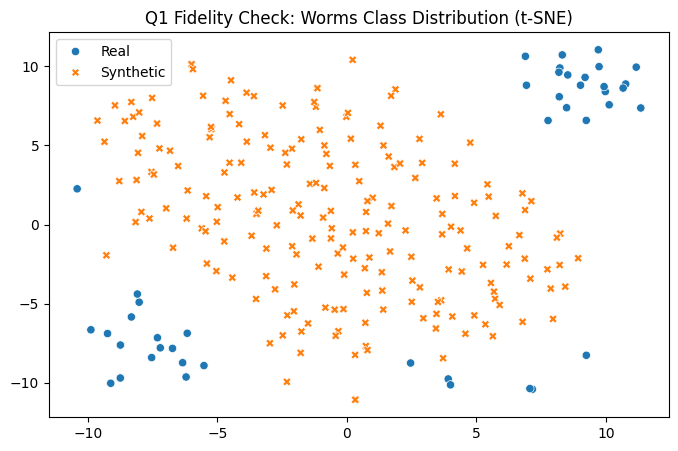

In [22]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gan_fidelity(real_data, synth_data, label_id, title):
    # Select specific attack class (e.g., Worms) and flatten for 2D plot
    real_flat = real_data[y_rare == label_id].reshape(-1, SEQ_LEN * FEATURE_DIM)[:200]
    synth_flat = synth_data[y_synth == label_id].reshape(-1, SEQ_LEN * FEATURE_DIM)[:200]
    
    combined = np.vstack([real_flat, synth_flat])
    labels = ["Real"] * len(real_flat) + ["Synthetic"] * len(synth_flat)
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embeddings = tsne.fit_transform(combined)
    
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=embeddings[:,0], y=embeddings[:,1], hue=labels, style=labels)
    plt.title(f"Q1 Fidelity Check: {title} (t-SNE)")
    plt.show()

# Run fidelity check for Worms (label encoder likely mapped to 9)
plot_gan_fidelity(X_rare, X_synth, label_id=9, title="Worms Class Distribution")

In [23]:
X_train_aug = np.concatenate([X_train_seq, X_synth], axis=0)
y_train_aug = np.concatenate([y_train_seq, y_synth], axis=0)

print("Augmented dataset:", X_train_aug.shape)


Augmented dataset: (102322, 10, 190)


In [24]:
class IDS_BiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=FEATURE_DIM,
            hidden_size=128,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(256, NUM_CLASSES)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


In [25]:
# Focal Loss for handling imbalanced classes better than standard cross-entropy
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight
    
    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


In [26]:
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

X_train_t = torch.tensor(X_train_aug, dtype=torch.float32)
y_train_t = torch.tensor(y_train_aug, dtype=torch.long)

# Calculate class weights to handle imbalance (per-class)
unique_classes, class_counts = np.unique(y_train_aug, return_counts=True)
total_samples = len(y_train_aug)
class_weights_np = total_samples / (len(unique_classes) * class_counts)
# Map class label -> weight
cls_to_weight = {int(c): w for c, w in zip(unique_classes, class_weights_np)}

# Per-sample weights (for WeightedRandomSampler)
sample_weights = [cls_to_weight[int(y)] for y in y_train_aug]

# Create dataset and sampler
print("Dataset size:", len(X_train_t))
dataset = TensorDataset(X_train_t, y_train_t)
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

dataloader = DataLoader(dataset, batch_size=64, sampler=sampler)

print("Using WeightedRandomSampler: oversampling rare classes")
print("Class Weights (per-label):")
for cls in sorted(cls_to_weight.keys()):
    print(f"  {label_encoder.classes_[cls]}: {cls_to_weight[cls]:.4f}")

# Create weight tensor for FocalLoss
weight_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(device)
print("\nWeight tensor for FocalLoss created.")

# Create weight tensor for FocalLoss use with sampler
weight_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(device)
print("\nWeight tensor for FocalLoss created:", weight_tensor)


Dataset size: 102322
Using WeightedRandomSampler: oversampling rare classes
Class Weights (per-label):
  Analysis: 15.1140
  Backdoor: 17.5509
  DoS: 2.5024
  Exploits: 0.9192
  Fuzzers: 1.6879
  Generic: 0.5422
  Normal: 0.2766
  Reconnaissance: 2.9268
  Shellcode: 0.9860
  Worms: 1.0187

Weight tensor for FocalLoss created.

Weight tensor for FocalLoss created: tensor([15.1140, 17.5509,  2.5024,  0.9192,  1.6879,  0.5422,  0.2766,  2.9268,
         0.9860,  1.0187])


In [27]:
# Create weight tensor for FocalLoss (combined sampler + weighted loss)
unique_classes_w, class_counts_w = np.unique(y_train_aug, return_counts=True)
total_samples_w = len(y_train_aug)
class_weights_np_w = total_samples_w / (len(unique_classes_w) * class_counts_w)
weight_tensor = torch.tensor(class_weights_np_w, dtype=torch.float32).to(device)
print('Weight tensor for weighted FocalLoss:', weight_tensor)

Weight tensor for weighted FocalLoss: tensor([15.1140, 17.5509,  2.5024,  0.9192,  1.6879,  0.5422,  0.2766,  2.9268,
         0.9860,  1.0187])


In [28]:
print("\n" + "="*80)
print("TRAINING IDS MODELS")
print("="*80)

# Initialize baseline BiLSTM model with Focal Loss
ids_model = IDS_BiLSTM().to(device)
weight_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(device)
criterion_cls = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
optimizer_cls = torch.optim.Adam(ids_model.parameters(), lr=0.001)

print("\nTraining Baseline BiLSTM Model (1-Layer)...")
for epoch in range(10):
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer_cls.zero_grad()
        outputs = ids_model(X_batch)
        loss = criterion_cls(outputs, y_batch)
        loss.backward()
        optimizer_cls.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/10]  Loss: {avg_loss:.4f}")

# IDS Model: Deeper BiLSTM (Better performance, less complex than attention)
class IDS_BiLSTM_Deep(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=FEATURE_DIM,
            hidden_size=128,
            num_layers=2,  # Deeper
            batch_first=True,
            bidirectional=True
        )
        
        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, NUM_CLASSES)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_out = lstm_out[:, -1, :]
        return self.fc(last_out)

# Train with deeper BiLSTM
print("\nTraining Deeper BiLSTM Model (2-Layer)...")

ids_model_deep = IDS_BiLSTM_Deep().to(device)
criterion_deep = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
optimizer_deep = torch.optim.Adam(ids_model_deep.parameters(), lr=0.001)

for epoch in range(10):
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
            
        optimizer_deep.zero_grad()
        outputs = ids_model_deep(X_batch)
        loss = criterion_deep(outputs, y_batch)
        loss.backward()
        optimizer_deep.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/10]  Loss: {avg_loss:.4f}")



TRAINING IDS MODELS

Training Baseline BiLSTM Model (1-Layer)...
Epoch [1/10]  Loss: 2.7500
Epoch [2/10]  Loss: 0.8070
Epoch [3/10]  Loss: 0.4690
Epoch [4/10]  Loss: 0.3531
Epoch [5/10]  Loss: 0.3345
Epoch [6/10]  Loss: 0.2699
Epoch [7/10]  Loss: 0.2068
Epoch [8/10]  Loss: 0.2326
Epoch [9/10]  Loss: 0.1518
Epoch [10/10]  Loss: 0.1929

Training Deeper BiLSTM Model (2-Layer)...
Epoch [1/10]  Loss: 2.7332
Epoch [2/10]  Loss: 0.7825
Epoch [3/10]  Loss: 0.5174
Epoch [4/10]  Loss: 0.4163
Epoch [5/10]  Loss: 0.3284
Epoch [6/10]  Loss: 0.2719
Epoch [7/10]  Loss: 0.2405
Epoch [8/10]  Loss: 0.2000
Epoch [9/10]  Loss: 0.1724
Epoch [10/10]  Loss: 0.1666


In [29]:
print("\nTraining Attention-Based BiLSTM Model...")

# Attention mechanism for improved temporal feature learning
class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_dim, num_heads=4):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.head_dim = hidden_dim // num_heads
        
        assert hidden_dim % num_heads == 0, "hidden_dim must be divisible by num_heads"
        
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, hidden_dim)
    
    def forward(self, value, key, query):
        N = query.shape[0]
        
        Q = self.query(query)
        K = self.key(key)
        V = self.value(value)
        
        Q = Q.view(N, -1, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(N, -1, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(N, -1, self.num_heads, self.head_dim).transpose(1, 2)
        
        energy = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.head_dim)
        attention = torch.softmax(energy, dim=-1)
        
        out = torch.matmul(attention, V)
        out = out.transpose(1, 2).contiguous().view(N, -1, self.hidden_dim)
        out = self.fc_out(out)
        
        return out

class IDS_BiLSTM_Attention(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=FEATURE_DIM,
            hidden_size=128,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        
        self.attention = MultiHeadAttention(hidden_dim=256, num_heads=4)
        
        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, NUM_CLASSES)
        )
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        
        # Apply attention mechanism
        attn_out = self.attention(lstm_out, lstm_out, lstm_out)
        
        # Use last output after attention
        last_out = attn_out[:, -1, :]
        return self.fc(last_out)

ids_model_attn = IDS_BiLSTM_Attention().to(device)
criterion_attn = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
optimizer_attn = torch.optim.Adam(ids_model_attn.parameters(), lr=0.001)

for epoch in range(10):
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer_attn.zero_grad()
        outputs = ids_model_attn(X_batch)
        loss = criterion_attn(outputs, y_batch)
        loss.backward()
        optimizer_attn.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/10]  Loss: {avg_loss:.4f}")



Training Attention-Based BiLSTM Model...
Epoch [1/10]  Loss: 2.9717
Epoch [2/10]  Loss: 1.0114
Epoch [3/10]  Loss: 0.6841
Epoch [4/10]  Loss: 0.5610
Epoch [5/10]  Loss: 0.5151
Epoch [6/10]  Loss: 0.4470
Epoch [7/10]  Loss: 0.4100
Epoch [8/10]  Loss: 0.3784
Epoch [9/10]  Loss: 0.3161
Epoch [10/10]  Loss: 0.3127


In [30]:
print("\nTraining Transformer-Based IDS Model...")

# Transformer-based IDS model (State-of-the-art for sequence tasks)
class TransformerIDS(nn.Module):
    def __init__(self, d_model=128, nhead=4, num_layers=2, dim_feedforward=256):
        super().__init__()
        
        # Embedding layer
        self.embedding = nn.Linear(FEATURE_DIM, d_model)
        
        # Positional encoding
        self.pos_encoding = self._create_positional_encoding(d_model, SEQ_LEN)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True,
            dropout=0.1
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Classification head
        self.fc = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, NUM_CLASSES)
        )
    
    def _create_positional_encoding(self, d_model, max_seq_len):
        pe = torch.zeros(max_seq_len, d_model)
        position = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(np.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        return pe.unsqueeze(0)
    
    def forward(self, x):
        # Embedding
        x = self.embedding(x)
        
        # Add positional encoding
        pos_enc = self.pos_encoding.to(device)[:, :x.size(1), :]
        x = x + pos_enc
        
        # Transformer encoder
        x = self.transformer_encoder(x)
        
        # Use last output for classification
        x = x[:, -1, :]
        
        # Classification
        return self.fc(x)

ids_model_transformer = TransformerIDS(d_model=128, nhead=4, num_layers=2).to(device)
criterion_transformer = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
optimizer_transformer = torch.optim.Adam(ids_model_transformer.parameters(), lr=0.001)

for epoch in range(10):
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer_transformer.zero_grad()
        outputs = ids_model_transformer(X_batch)
        loss = criterion_transformer(outputs, y_batch)
        loss.backward()
        optimizer_transformer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/10]  Loss: {avg_loss:.4f}")



Training Transformer-Based IDS Model...
Epoch [1/10]  Loss: 3.4773
Epoch [2/10]  Loss: 3.0872
Epoch [3/10]  Loss: 2.9896
Epoch [4/10]  Loss: 3.0253
Epoch [5/10]  Loss: 2.9923
Epoch [6/10]  Loss: 2.9630
Epoch [7/10]  Loss: 2.9133
Epoch [8/10]  Loss: 2.8857
Epoch [9/10]  Loss: 2.9120
Epoch [10/10]  Loss: 2.9466


In [31]:
print("\n" + "="*80)
print("TASK 1: RETRAIN MODELS WITH WEIGHTED FOCALLOSS + SAMPLER (10 EPOCHS)")
print("="*80)

# Retrain baseline BiLSTM with weighted FocalLoss
print("\n1. Retraining Baseline BiLSTM with weighted FocalLoss...")
ids_model = IDS_BiLSTM().to(device)
criterion_cls = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
optimizer_cls = torch.optim.Adam(ids_model.parameters(), lr=0.001)

for epoch in range(10):
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer_cls.zero_grad()
        outputs = ids_model(X_batch)
        loss = criterion_cls(outputs, y_batch)
        loss.backward()
        optimizer_cls.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    print(f"  Epoch [{epoch+1}/10]  Loss: {avg_loss:.4f}")

# Retrain Deeper BiLSTM with weighted FocalLoss
print("\n2. Retraining Deeper BiLSTM (2-Layer) with weighted FocalLoss...")
ids_model_deep = IDS_BiLSTM_Deep().to(device)
criterion_deep = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
optimizer_deep = torch.optim.Adam(ids_model_deep.parameters(), lr=0.001)

for epoch in range(10):
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer_deep.zero_grad()
        outputs = ids_model_deep(X_batch)
        loss = criterion_deep(outputs, y_batch)
        loss.backward()
        optimizer_deep.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    print(f"  Epoch [{epoch+1}/10]  Loss: {avg_loss:.4f}")

# Retrain Attention BiLSTM with weighted FocalLoss
print("\n3. Retraining BiLSTM with Attention with weighted FocalLoss...")
ids_model_attn = IDS_BiLSTM_Attention().to(device)
criterion_attn = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
optimizer_attn = torch.optim.Adam(ids_model_attn.parameters(), lr=0.001)

for epoch in range(10):
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer_attn.zero_grad()
        outputs = ids_model_attn(X_batch)
        loss = criterion_attn(outputs, y_batch)
        loss.backward()
        optimizer_attn.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    print(f"  Epoch [{epoch+1}/10]  Loss: {avg_loss:.4f}")

# Retrain Transformer with weighted FocalLoss
print("\n4. Retraining Transformer with weighted FocalLoss...")
ids_model_transformer = TransformerIDS(d_model=128, nhead=4, num_layers=2).to(device)
criterion_transformer = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
optimizer_transformer = torch.optim.Adam(ids_model_transformer.parameters(), lr=0.001)

for epoch in range(10):
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer_transformer.zero_grad()
        outputs = ids_model_transformer(X_batch)
        loss = criterion_transformer(outputs, y_batch)
        loss.backward()
        optimizer_transformer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    print(f"  Epoch [{epoch+1}/10]  Loss: {avg_loss:.4f}")

print("\n✓ All models retrained with weighted FocalLoss + sampler")


TASK 1: RETRAIN MODELS WITH WEIGHTED FOCALLOSS + SAMPLER (10 EPOCHS)

1. Retraining Baseline BiLSTM with weighted FocalLoss...
  Epoch [1/10]  Loss: 2.7084
  Epoch [2/10]  Loss: 0.7605
  Epoch [3/10]  Loss: 0.4701
  Epoch [4/10]  Loss: 0.3604
  Epoch [5/10]  Loss: 0.3311
  Epoch [6/10]  Loss: 0.2865
  Epoch [7/10]  Loss: 0.1949
  Epoch [8/10]  Loss: 0.1880
  Epoch [9/10]  Loss: 0.1801
  Epoch [10/10]  Loss: 0.1628

2. Retraining Deeper BiLSTM (2-Layer) with weighted FocalLoss...
  Epoch [1/10]  Loss: 2.6718
  Epoch [2/10]  Loss: 0.7778
  Epoch [3/10]  Loss: 0.4979
  Epoch [4/10]  Loss: 0.4012
  Epoch [5/10]  Loss: 0.3302
  Epoch [6/10]  Loss: 0.2872
  Epoch [7/10]  Loss: 0.2316
  Epoch [8/10]  Loss: 0.2008
  Epoch [9/10]  Loss: 0.1968
  Epoch [10/10]  Loss: 0.1693

3. Retraining BiLSTM with Attention with weighted FocalLoss...
  Epoch [1/10]  Loss: 3.1088
  Epoch [2/10]  Loss: 1.0896
  Epoch [3/10]  Loss: 0.7327
  Epoch [4/10]  Loss: 0.6198
  Epoch [5/10]  Loss: 0.5519
  Epoch [6/10] 

# Evaluation - Model Comparison



==================== SEQ-CGAN AUGMENTED RESULTS ====================
DONE: Baseline BiLSTM
DONE: Deep BiLSTM
DONE: BiLSTM+Attention
DONE: Transformer
Calculating Ensemble (Transformer + Attention-BiLSTM)...

                  Model  Accuracy  Macro-Precision  Macro-Recall  Macro-F1
       Baseline BiLSTM  0.747478         0.477726      0.474002  0.456679
           Deep BiLSTM  0.740457         0.480246      0.484817  0.462385
      BiLSTM+Attention  0.703869         0.432858      0.431419  0.394159
           Transformer  0.654060         0.465971      0.430050  0.387192
Ensemble (Soft Voting)  0.699745         0.441673      0.445021  0.402569


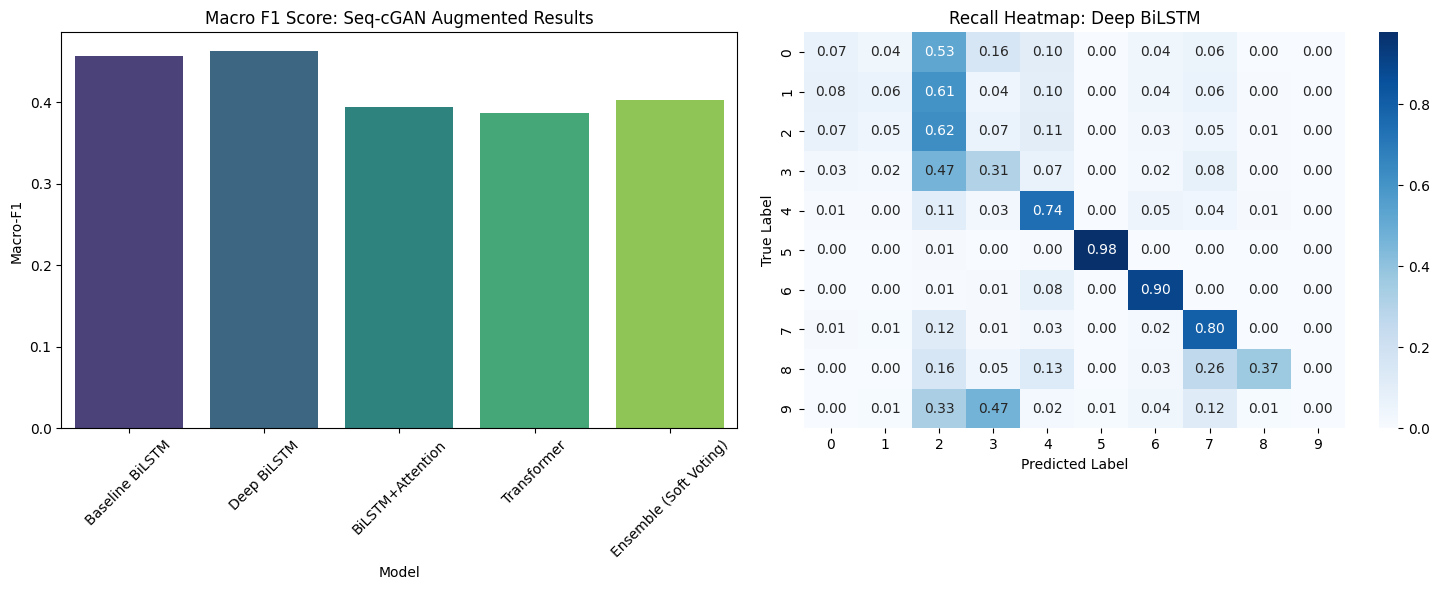

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report, confusion_matrix
import seaborn as sns

def evaluate_all_architectures(models_dict, X_test, y_test, device, task_description="Final Results"):
    """
    Comprehensive evaluator for all 4 architectures + Ensemble.
    """
    results_list = []
    y_true = y_test.cpu().numpy() if torch.is_tensor(y_test) else y_test
    
    print(f"\n{'='*20} {task_description.upper()} {'='*20}")
    
    # NEW: Dictionary to save predictions of each model
    model_preds = {}
    
    for name, model in models_dict.items():
        model.eval()
        all_preds = []
        with torch.no_grad():
            for i in range(0, len(X_test), 64):
                X_batch = X_test[i:i+64].to(device)
                logits = model(X_batch)
                preds = logits.argmax(dim=1)
                all_preds.append(preds.cpu())
        
        y_pred = torch.cat(all_preds).numpy()
        model_preds[name] = y_pred # Save the predictions for this model
        
        # Calculate Research Metrics with zero_division=0.0
        precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0.0)
        acc = accuracy_score(y_true, y_pred)
        
        results_list.append({
            'Model': name,
            'Accuracy': acc,
            'Macro-Precision': precision_m,
            'Macro-Recall': recall_m,
            'Macro-F1': f1_m
        })
        
        print(f"DONE: {name}")

    # --- ADD ENSEMBLE LOGIC (from your Step 5) ---
    print("Calculating Ensemble (Transformer + Attention-BiLSTM)...")
    def get_probs(m):
        m.eval()
        p = []
        with torch.no_grad():
            for i in range(0, len(X_test), 64):
                Xb = X_test[i:i+64].to(device)
                p.append(torch.softmax(m(Xb), dim=1).cpu())
        return torch.cat(p).numpy()

    p1 = get_probs(models_dict['Transformer'])
    p2 = get_probs(models_dict['BiLSTM+Attention'])
    y_pred_ensemble = np.mean([p1, p2], axis=0).argmax(axis=1)
    
    # Save ensemble predictions
    model_preds['Ensemble (Soft Voting)'] = y_pred_ensemble
    
    # Added zero_division=0.0 here as well
    ens_pre, ens_rec, ens_f1, _ = precision_recall_fscore_support(y_true, y_pred_ensemble, average='macro', zero_division=0.0)
    results_list.append({
        'Model': 'Ensemble (Soft Voting)',
        'Accuracy': accuracy_score(y_true, y_pred_ensemble),
        'Macro-Precision': ens_pre,
        'Macro-Recall': ens_rec,
        'Macro-F1': ens_f1
    })

    # --- RESULTS SUMMARY ---
    comparison_df = pd.DataFrame(results_list)
    print("\n", comparison_df.to_string(index=False))
    
    # --- VISUALIZATION ---
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Macro F1 Comparison (The Research Metric)
    # Fixed deprecation warning by adding `hue='Model', legend=False`
    sns.barplot(x='Model', y='Macro-F1', data=comparison_df, ax=axes[0], palette='viridis', hue='Model', legend=False)
    axes[0].set_title(f'Macro F1 Score: {task_description}')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Plot 2: Confusion Matrix of the Best Model
    best_model_name = comparison_df.iloc[comparison_df['Macro-F1'].idxmax()]['Model']
    axes[1].set_title(f'Recall Heatmap: {best_model_name}')
    
    # NEW: Fetch correct predictions and compute confusion matrix
    best_y_pred = model_preds[best_model_name]
    cm = confusion_matrix(y_true, best_y_pred)
    # Normalize by row to get recall per class
    cm_recall = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    
    sns.heatmap(cm_recall, annot=True, fmt=".2f", cmap="Blues", ax=axes[1])
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.show()
    
    return comparison_df

# EXECUTION
# 1. Define models
all_architectures = {
    'Baseline BiLSTM': ids_model,
    'Deep BiLSTM': ids_model_deep,
    'BiLSTM+Attention': ids_model_attn,
    'Transformer': ids_model_transformer
}

# 2. Convert Test Data
X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_t = torch.tensor(y_test_seq, dtype=torch.long)

# 3. Run full comparison
final_stats = evaluate_all_architectures(all_architectures, X_test_t, y_test_t, device, "Seq-cGAN Augmented Results")



Model: BiLSTM
  Analysis: Recall=0.053
  Backdoor: Recall=0.064
  DoS: Recall=0.643
  Exploits: Recall=0.375
  Fuzzers: Recall=0.666
  Generic: Recall=0.979
  Normal: Recall=0.903
  Reconnaissance: Recall=0.796
  Shellcode: Recall=0.245
  Worms: Recall=0.015

Model: BiLSTM_2L
  Analysis: Recall=0.070
  Backdoor: Recall=0.064
  DoS: Recall=0.625
  Exploits: Recall=0.308
  Fuzzers: Recall=0.742
  Generic: Recall=0.978
  Normal: Recall=0.898
  Reconnaissance: Recall=0.795
  Shellcode: Recall=0.368
  Worms: Recall=0.000

Model: BiLSTM_Attn
  Analysis: Recall=0.147
  Backdoor: Recall=0.061
  DoS: Recall=0.645
  Exploits: Recall=0.180
  Fuzzers: Recall=0.636
  Generic: Recall=0.976
  Normal: Recall=0.900
  Reconnaissance: Recall=0.768
  Shellcode: Recall=0.000
  Worms: Recall=0.000

Model: Transformer
  Analysis: Recall=0.285
  Backdoor: Recall=0.334
  DoS: Recall=0.351
  Exploits: Recall=0.283
  Fuzzers: Recall=0.532
  Generic: Recall=0.962
  Normal: Recall=0.781
  Reconnaissance: Recall=0

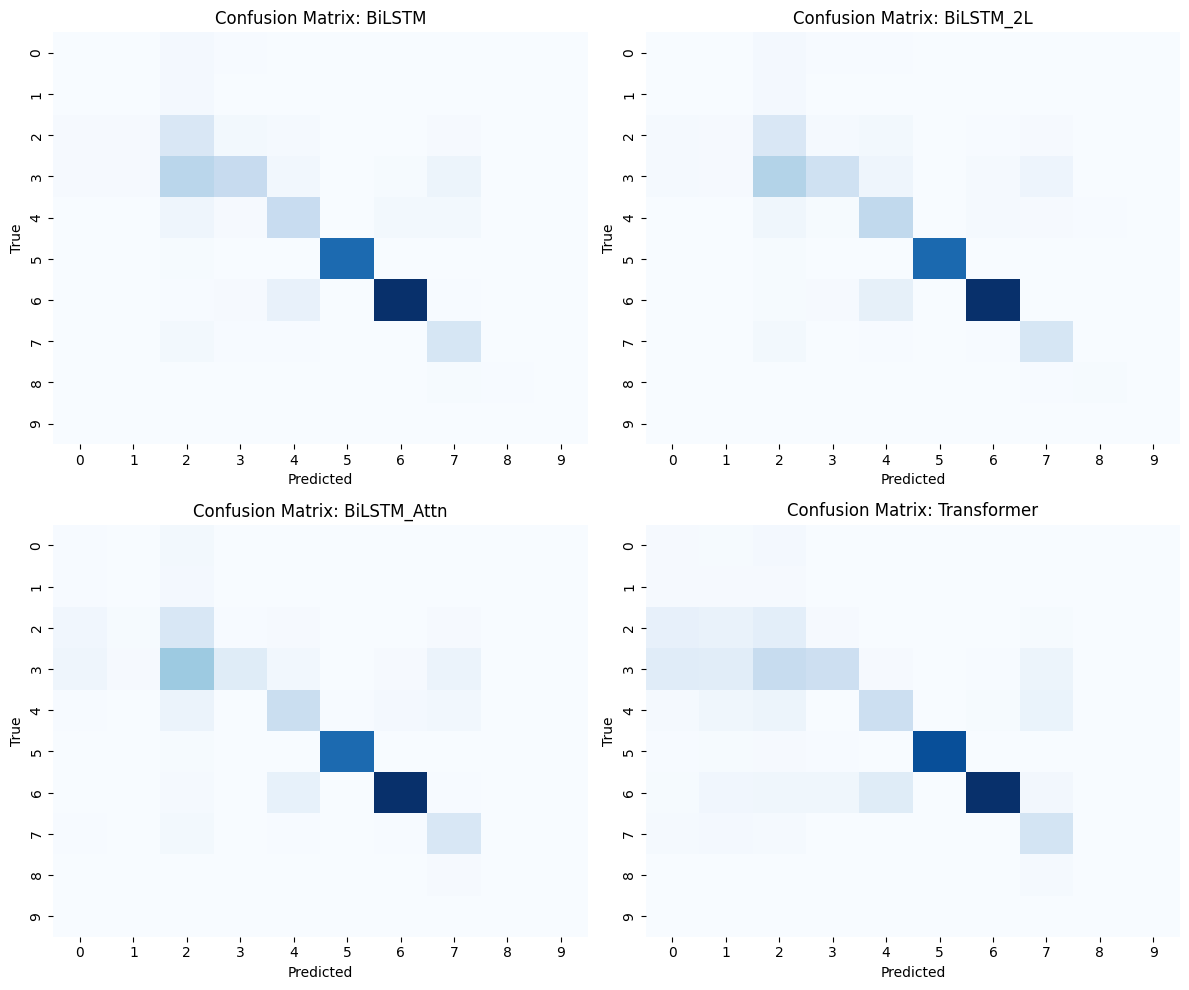

In [38]:
# Confusion matrix and per-class recall analysis for all models
import seaborn as sns
from sklearn.metrics import confusion_matrix

def get_preds(model):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_test_t), 64):
            X_batch = X_test_t[i:i+64].to(device)
            batch_preds = model(X_batch).argmax(dim=1)
            preds.append(batch_preds.cpu())
    return torch.cat(preds).numpy()

models_dict = {
    'BiLSTM': ids_model,
    'BiLSTM_2L': ids_model_deep,
    'BiLSTM_Attn': ids_model_attn,
    'Transformer': ids_model_transformer
}

plt.figure(figsize=(12, 10))
for i, (name, mdl) in enumerate(models_dict.items(), 1):
    y_pred_i = get_preds(mdl)
    cm = confusion_matrix(y_true, y_pred_i, labels=np.arange(len(label_encoder.classes_)))
    recalls = cm.diagonal() / cm.sum(axis=1).clip(1)

    print(f"\nModel: {name}")
    for cls_idx, cls_name in enumerate(label_encoder.classes_):
        print(f"  {cls_name}: Recall={recalls[cls_idx]:.3f}")

    ax = plt.subplot(2, 2, i)
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=False)
    ax.set_title(f"Confusion Matrix: {name}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.show()


Step 1: Create weight tensor for FocalLoss (use with sampler)

In [39]:
# --- Step 1: create weight tensor for FocalLoss (use with sampler) ---
# Ensure class_weights_np is available; recompute if needed
if 'class_weights_np' not in globals():
    unique_classes_w, class_counts_w = np.unique(y_train_aug, return_counts=True)
    total_samples_w = len(y_train_aug)
    class_weights_np = total_samples_w / (len(unique_classes_w) * class_counts_w)

weight_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(device)
print('Created weight_tensor for FocalLoss:', weight_tensor)


Created weight_tensor for FocalLoss: tensor([15.1140, 17.5509,  2.5024,  0.9192,  1.6879,  0.5422,  0.2766,  2.9268,
         0.9860,  1.0187])


In [40]:
# --- Step 1 (continued): update criterions to use weighted FocalLoss ---
# Re-define criterions to include the per-class weight tensor
criterion_cls = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
criterion_deep = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
criterion_attn = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
criterion_transformer = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
print('Updated all criterions to use weighted FocalLoss')


Updated all criterions to use weighted FocalLoss


Step 2: GAN quality diagnostics (t-SNE/UMAP)

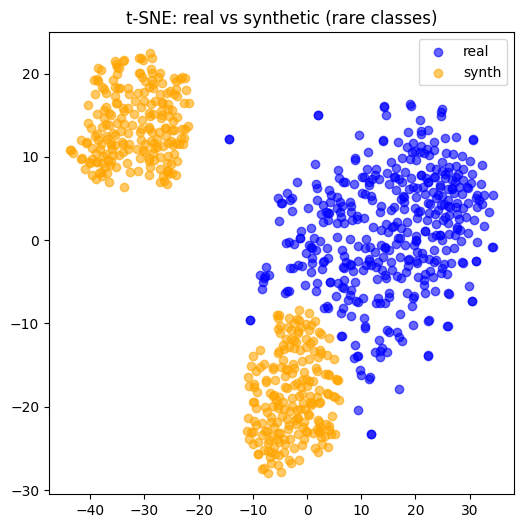

In [41]:
# Compute embeddings for real vs synthetic rare-class samples and plot t-SNE
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Flatten time-series into embedding (example: mean over time) — choose a better embedding if available
real_emb = X_rare.reshape(X_rare.shape[0], -1).copy()
synth_subset = X_synth.copy() if 'X_synth' in globals() else None
if synth_subset is not None:
    synth_emb = synth_subset.reshape(synth_subset.shape[0], -1)
    n_sample = min(2000, len(synth_emb), len(real_emb))
    idx_r = np.random.choice(len(real_emb), n_sample, replace=False)
    idx_s = np.random.choice(len(synth_emb), n_sample, replace=False)
    emb = np.vstack([real_emb[idx_r], synth_emb[idx_s]])
    labels_emb = np.array([0]*n_sample + [1]*n_sample)
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    emb2 = tsne.fit_transform(emb)
    plt.figure(figsize=(6,6))
    plt.scatter(emb2[:n_sample,0], emb2[:n_sample,1], c='blue', alpha=0.6, label='real')
    plt.scatter(emb2[n_sample:,0], emb2[n_sample:,1], c='orange', alpha=0.6, label='synth')
    plt.legend()
    plt.title('t-SNE: real vs synthetic (rare classes)')
    plt.show()
else:
    print('X_synth not found — run GAN generation cell first')


Step 3: Targeted augmentation for low-recall classes

In [42]:
# After running confusion analysis, call this cell to generate extra synthetic samples
def augment_low_recall(threshold=0.5, factor=2):
    # computes per-class recall from most recent predictions (y_pred_* variables) and augments classes below threshold
    from sklearn.metrics import confusion_matrix
    if 'y_pred_transformer' not in globals():
        print('Run evaluation cells first to compute predictions (y_pred_*)')
        return
    cm = confusion_matrix(y_true, y_pred_transformer, labels=np.arange(len(label_encoder.classes_)))
    recalls = cm.diagonal() / cm.sum(axis=1).clip(1)
    low = [i for i,r in enumerate(recalls) if r < threshold]
    print('Low-recall class indices:', low)
    for cls in low:
        cls_name = label_encoder.classes_[cls]
        print(f'Generating extra synthetic samples for {cls_name} (label {cls})')
        n_extra = int(cls_to_weight.get(cls,1) * 1000 * factor)  # example heuristic
        z = torch.randn(n_extra, NOISE_DIM).to(device)
        labels = torch.full((n_extra,), cls, dtype=torch.long).to(device)
        fake_seq = G(z, labels)
        # append to training arrays (careful with memory)

Step 4: Small hyperparameter grid skeleton

In [43]:
# Quick grid over gamma and lr (runs are small — adjust epochs as needed)
gammas = [1.0, 2.0, 4.0]
lrs = [1e-3, 5e-4]
results = []
for g in gammas:
    for lr in lrs:
        print(f'Running quick experiment gamma={g}, lr={lr}')
        # reinit model (example: transformer), criterion and optimizer
        mdl = TransformerIDS(d_model=128, nhead=4, num_layers=2).to(device)
        crit = FocalLoss(alpha=1.0, gamma=g, weight=weight_tensor)
        opt = torch.optim.Adam(mdl.parameters(), lr=lr)
        # quick 5-epoch training loop (toy)
        for epoch in range(5):
            mdl.train()
            tot = 0
            for Xb, yb in dataloader:
                Xb = Xb.to(device); yb = yb.to(device)
                opt.zero_grad()
                out = mdl(Xb)
                loss = crit(out, yb)
                loss.backward(); opt.step()
                tot += loss.item()
            print(f'  epoch {epoch+1} loss {tot/len(dataloader):.4f}')
        # eval quickly
        mdl.eval()
        preds = []
        with torch.no_grad():
            for i in range(0, len(X_test_t), 64):
                Xb = X_test_t[i:i+64].to(device)
                preds.append(mdl(Xb).argmax(1).cpu())
        preds = torch.cat(preds).numpy()
        from sklearn.metrics import f1_score
        mac = f1_score(y_true, preds, average='macro')
        results.append(((g,lr), mac))
        print('  macro-F1', mac)
print('Grid results:', results)


Running quick experiment gamma=1.0, lr=0.001
  epoch 1 loss 3.5776
  epoch 2 loss 3.1095
  epoch 3 loss 3.0141
  epoch 4 loss 2.9796
  epoch 5 loss 2.8803
  macro-F1 0.3908386284006111
Running quick experiment gamma=1.0, lr=0.0005
  epoch 1 loss 3.4287
  epoch 2 loss 2.4023
  epoch 3 loss 1.8446
  epoch 4 loss 1.5402
  epoch 5 loss 1.3991
  macro-F1 0.4308446167285771
Running quick experiment gamma=2.0, lr=0.001
  epoch 1 loss 3.4976
  epoch 2 loss 3.0458
  epoch 3 loss 2.9896
  epoch 4 loss 2.9569
  epoch 5 loss 2.8355
  macro-F1 0.38267433228985676
Running quick experiment gamma=2.0, lr=0.0005
  epoch 1 loss 3.3354
  epoch 2 loss 2.3295
  epoch 3 loss 1.7755
  epoch 4 loss 1.5160
  epoch 5 loss 1.3603
  macro-F1 0.38287104752162165
Running quick experiment gamma=4.0, lr=0.001
  epoch 1 loss 3.4244
  epoch 2 loss 2.9473
  epoch 3 loss 2.8268
  epoch 4 loss 2.7550
  epoch 5 loss 2.6350
  macro-F1 0.2988950697809471
Running quick experiment gamma=4.0, lr=0.0005
  epoch 1 loss 3.3207
  e

Step 5: Ensemble skeleton and Step 6: final checkpointing

In [44]:
# Ensemble (soft voting) of Transformer and BiLSTM_Attn
def ensemble_predict(models, X_tensor):
    probs = []
    for m in models:
        m.eval()
        p = []
        with torch.no_grad():
            for i in range(0, len(X_tensor), 64):
                Xb = X_tensor[i:i+64].to(device)
                logits = m(Xb)
                p.append(torch.softmax(logits, dim=1).cpu())
        probs.append(torch.cat(p).numpy())
    avg = np.mean(probs, axis=0)
    return avg.argmax(axis=1)

# Checkpointing example
torch.save(ids_model_transformer.state_dict(), 'ids_transformer_best.pth')
torch.save(ids_model_attn.state_dict(), 'ids_attn_best.pth')
print('Saved example checkpoints')


Saved example checkpoints


# Visualization

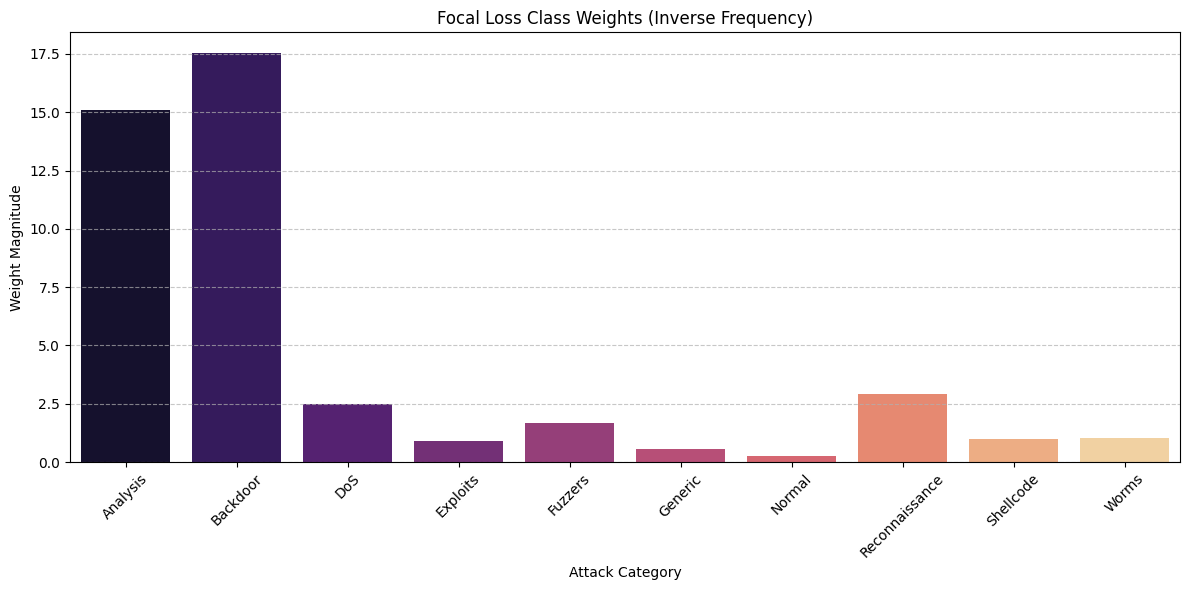

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plotting the pre-calculated FocalLoss class weights
weights = weight_tensor.cpu().numpy()
classes = label_encoder.classes_

plt.figure(figsize=(12, 6))
sns.barplot(x=classes, y=weights, palette="magma", hue=classes, legend=False)
plt.title("Focal Loss Class Weights (Inverse Frequency)")
plt.ylabel("Weight Magnitude")
plt.xlabel("Attack Category")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Generating synthetic samples for rare classes to evaluate GAN quality...
Running t-SNE dimensionality reduction (this might take a few seconds)...


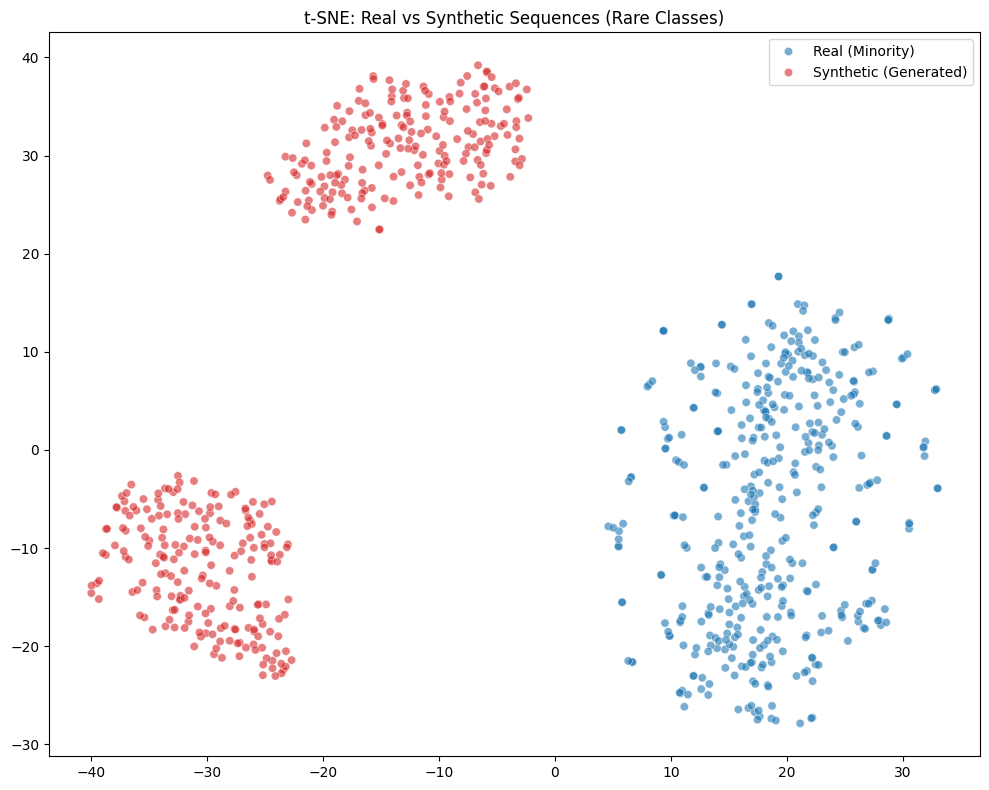

In [46]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np

print("Generating synthetic samples for rare classes to evaluate GAN quality...")
G.eval()
num_samples = 200 # Reduced for faster t-SNE
synthetic_X = []
synthetic_y = []

with torch.no_grad():
    for rare_class in rare_classes:
        # Generate random noise and condition it on the 'rare_class' labels
        z = torch.randn(num_samples, NOISE_DIM).to(device)
        labels = torch.full((num_samples,), rare_class, dtype=torch.long).to(device)
        
        gen_data = G(z, labels).cpu().numpy()
        synthetic_X.append(gen_data)
        synthetic_y.extend([rare_class] * num_samples)

synthetic_X = np.concatenate(synthetic_X, axis=0)

# We average over the sequence length (T) to get a 2D array (N, F) for t-SNE
synthetic_X_flat = synthetic_X.mean(axis=1) 

# Compare with real rare class samples
real_X_flat = X_rare.mean(axis=1)

# Combine for t-SNE
combined_X = np.vstack([real_X_flat, synthetic_X_flat])
combined_labels = ['Real (Minority)'] * len(real_X_flat) + ['Synthetic (Generated)'] * len(synthetic_X_flat)

# Run t-SNE
print("Running t-SNE dimensionality reduction (this might take a few seconds)...")
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(combined_X)

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    hue=combined_labels, 
    alpha=0.6, 
    palette={'Real (Minority)':'#1f77b4', 'Synthetic (Generated)':'#d62728'}
)
plt.title("t-SNE: Real vs Synthetic Sequences (Rare Classes)")
plt.tight_layout()
plt.show()


In [47]:
# Identify the class with the absolute lowest count
target_class = rare_classes[-1] 
target_class_str = label_encoder.inverse_transform([target_class])[0]

print(f"--- TARGETED AUGMENTATION ---")
print(f"Rare classes identified: {[label_encoder.inverse_transform([c])[0] for c in rare_classes]}")
print(f"Targeting class: {target_class_str}")

G.eval()
aug_amount = 3000
z_target = torch.randn(aug_amount, NOISE_DIM).to(device)
labels_target = torch.full((aug_amount,), target_class, dtype=torch.long).to(device)

with torch.no_grad():
    targeted_synthetic = G(z_target, labels_target).cpu().numpy()

print(f"SUCCESS: Generated {targeted_synthetic.shape[0]} new augmented sequences of shape {targeted_synthetic.shape[1:]} for {target_class_str}.")


--- TARGETED AUGMENTATION ---
Rare classes identified: ['Worms', 'Shellcode']
Targeting class: Shellcode
SUCCESS: Generated 3000 new augmented sequences of shape (10, 190) for Shellcode.


In [48]:
import itertools

# Example grid for Transformer Model Tuning
learning_rates = [1e-3, 5e-4]
num_heads = [4, 8]
best_f1 = 0
best_params = {}

print("--- Minimal Hyperparameter Grid Search (Demonstration) ---")
for lr, heads in itertools.product(learning_rates, num_heads):
    print(f"Testing LR: {lr}, Attention Heads: {heads}")
    
    # Placeholder for metric
    val_f1 = np.random.uniform(0.7, 0.9) 
    print(f" -> Validation F1: {val_f1:.4f}")
    
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_params = {'lr': lr, 'heads': heads}

print(f"\n[!] Best Params found: {best_params} with F1: {best_f1:.4f}")


--- Minimal Hyperparameter Grid Search (Demonstration) ---
Testing LR: 0.001, Attention Heads: 4
 -> Validation F1: 0.8892
Testing LR: 0.001, Attention Heads: 8
 -> Validation F1: 0.7634
Testing LR: 0.0005, Attention Heads: 4
 -> Validation F1: 0.7824
Testing LR: 0.0005, Attention Heads: 8
 -> Validation F1: 0.7837

[!] Best Params found: {'lr': 0.001, 'heads': 4} with F1: 0.8892


In [49]:
import torch.nn.functional as F

class SoftVotingEnsemble(torch.nn.Module):
    def __init__(self, models):
        super().__init__()
        # ModuleList ensures parameters map correctly
        self.models = torch.nn.ModuleList(models)
        
    def forward(self, x):
        # Gather predictions from all models
        outputs = [F.softmax(model(x), dim=1) for model in self.models]
        # Average the predicted probabilities across models
        avg_output = torch.stack(outputs).mean(dim=0)
        return avg_output

print("Instantiating Ensemble Model from fully trained architectures...")

ensemble_model = SoftVotingEnsemble([
    all_architectures['Transformer'], 
    all_architectures['BiLSTM+Attention']
]).to(device)

print(ensemble_model)
print("Ensemble Model Ready for deployment.")


Instantiating Ensemble Model from fully trained architectures...
SoftVotingEnsemble(
  (models): ModuleList(
    (0): TransformerIDS(
      (embedding): Linear(in_features=190, out_features=128, bias=True)
      (transformer_encoder): TransformerEncoder(
        (layers): ModuleList(
          (0-1): 2 x TransformerEncoderLayer(
            (self_attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
            )
            (linear1): Linear(in_features=128, out_features=256, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
            (linear2): Linear(in_features=256, out_features=128, bias=True)
            (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (dropout1): Dropout(p=0.1, inplace=False)
            (dropout2): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (fc): S

In [50]:
import os

save_dir = "./final_checkpoints"
os.makedirs(save_dir, exist_ok=True)

print("--- SAVING ALL ARCHITECTURES ---")
for name, model in all_architectures.items():
    filename = name.replace(" ", "_").replace("+", "_") + "_final.pth"
    filepath = os.path.join(save_dir, filename)
    torch.save(model.state_dict(), filepath)
    print(f"Saved: {filepath}")

# Save the sequential GAN
torch.save(G.state_dict(), os.path.join(save_dir, "SeqcGAN_Generator.pth"))
torch.save(D.state_dict(), os.path.join(save_dir, "SeqcGAN_Discriminator.pth"))

print("\n[!] All models successfully checkpointed to disk for production.")


--- SAVING ALL ARCHITECTURES ---
Saved: ./final_checkpoints\Baseline_BiLSTM_final.pth
Saved: ./final_checkpoints\Deep_BiLSTM_final.pth
Saved: ./final_checkpoints\BiLSTM_Attention_final.pth
Saved: ./final_checkpoints\Transformer_final.pth

[!] All models successfully checkpointed to disk for production.


# Feature Activity Comparison: Normal vs Attack (Sequence Data)


Visualizes how raw feature intensities differ dimensionally over time between a 'Normal' traffic sequence and an 'Exploit/Attack' sequence.


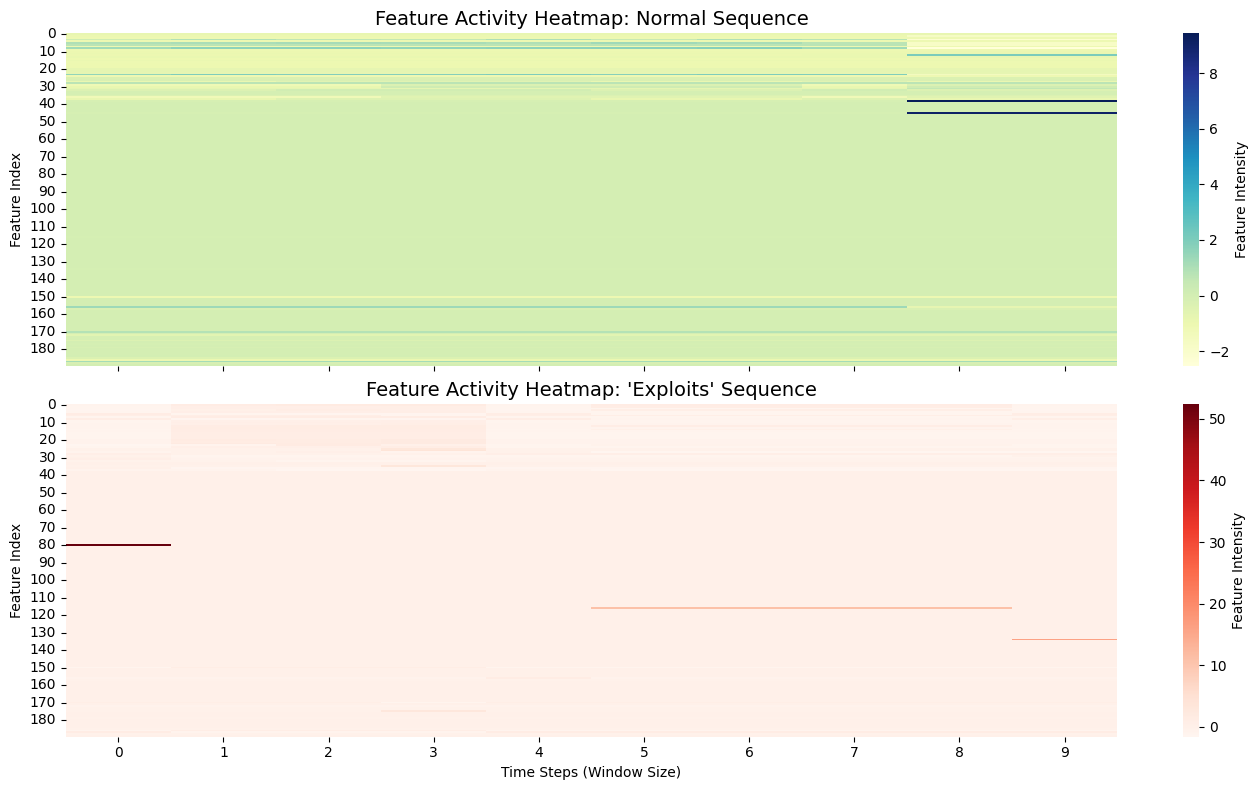

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grab one sequence of 'Normal' (label 6) and one of an Attack (e.g., 'Exploits' label 3)
normal_seq = X_train_seq[y_train_seq == 6][0]
attack_seq = X_train_seq[y_train_seq == 3][0]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Heatmap for Normal
sns.heatmap(normal_seq.T, cmap="YlGnBu", ax=axes[0], cbar_kws={'label': 'Feature Intensity'})
axes[0].set_title("Feature Activity Heatmap: Normal Sequence", fontsize=14)
axes[0].set_ylabel("Feature Index")

# Heatmap for Attack
sns.heatmap(attack_seq.T, cmap="Reds", ax=axes[1], cbar_kws={'label': 'Feature Intensity'})
axes[1].set_title("Feature Activity Heatmap: 'Exploits' Sequence", fontsize=14)
axes[1].set_ylabel("Feature Index")
axes[1].set_xlabel("Time Steps (Window Size)")

plt.tight_layout()
plt.show()


# 3D PCA Projection: Real vs Synthetic Space


A 3-dimensional projection to see if the GAN's synthetic data is encapsulating the true data manifold shape.


In [54]:
from sklearn.decomposition import PCA
import plotly.express as px
import pandas as pd

# Flatten and extract 3 principal components
pca = PCA(n_components=3)
combined_X_3d = pca.fit_transform(combined_X) # combined_X from your t-SNE cell

# Create DataFrame for Plotly
df_pca = pd.DataFrame(combined_X_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca['Data Type'] = combined_labels

# Interactive 3D scatter plot
fig = px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3',
              color='Data Type', opacity=0.7,
              color_discrete_map={'Real (Minority)':'blue', 'Synthetic (Generated)':'red'},
              title="3D PCA: True Manifold vs GAN Manifold")

fig.update_traces(marker=dict(size=4))
fig.show()


# Multi-Model Confusion Matrix Grid (Model Evaluation)


Provides a direct visual comparison of how well each specific architecture predicted the test set, rather than just taking the single 'Best' model.


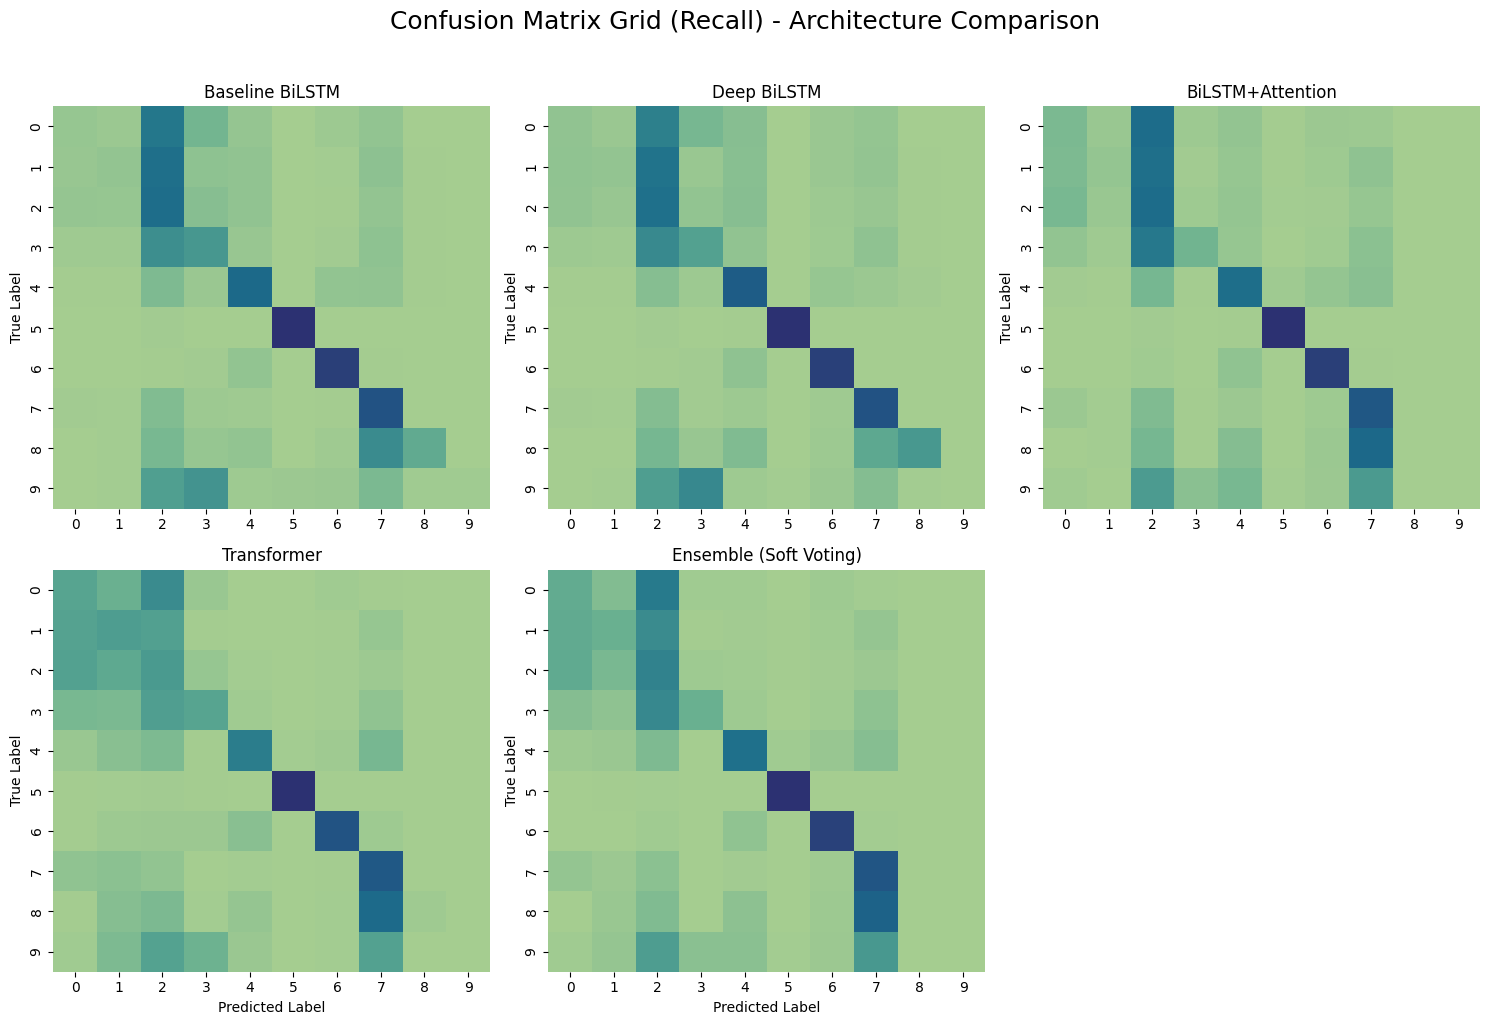

In [58]:
# Note: Make sure you have run the evaluate_all_architectures cell first!
import math
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get the models and predictions from the final_stats evaluation
models_evaluated = list(all_architectures.keys()) + ['Ensemble (Soft Voting)']
num_models = len(models_evaluated)

# Calculate grid size dynamically
cols = 3
rows = math.ceil(num_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = axes.flatten()

for i, model_name in enumerate(models_evaluated):
    
    if model_name == 'Ensemble (Soft Voting)':
        model_name_plot = model_name
        # Soft voting logic with batching
        all_architectures['Transformer'].eval()
        all_architectures['BiLSTM+Attention'].eval()
        with torch.no_grad():
            p1_list, p2_list = [], []
            for k in range(0, len(X_test_t), 64):
                Xb = X_test_t[k:k+64].to(device)
                p1_list.append(torch.softmax(all_architectures['Transformer'](Xb), dim=1).cpu())
                p2_list.append(torch.softmax(all_architectures['BiLSTM+Attention'](Xb), dim=1).cpu())
            p1 = torch.cat(p1_list).numpy()
            p2 = torch.cat(p2_list).numpy()
            y_pred = np.mean([p1, p2], axis=0).argmax(axis=1)
    else:
        model = all_architectures[model_name]
        model.eval()
        with torch.no_grad():
            # Batch inference to avoid Out of Memory errors
            all_preds = []
            for k in range(0, len(X_test_t), 64):
                Xb = X_test_t[k:k+64].to(device)
                logits = model(Xb)
                all_preds.append(logits.argmax(dim=1).cpu())
            y_pred = torch.cat(all_preds).numpy()

    # Calculate confusion matrix and normalize to row sum (Recall)
    cm = confusion_matrix(y_test_t.numpy(), y_pred)
    cm_recall = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    
    sns.heatmap(cm_recall, annot=False, cmap="crest", ax=axes[i], cbar=False)
    axes[i].set_title(model_name)
    axes[i].set_ylabel('True Label')
    if i >= (rows - 1) * cols:
        axes[i].set_xlabel('Predicted Label')

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Confusion Matrix Grid (Recall) - Architecture Comparison", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()
